# 06 — Advanced path: soft segments, hierarchy, time stability, scoring API

## Why

Production CRM rarely wants a single hard integer forever:

- **Soft membership** — probability of being VIP vs Core (GMM responsibilities)  
- **Hierarchy** — first VIP vs rest, then sub-segment the rest  
- **Stability over time** — re-fit at successive as-of dates; track ARI / size drift  
- **Scoring API** — `customer features → segment + confidence + action`  
- **Playbooks** — named KPI-linked actions for A/B design  

Notebooks 01–03 remain the baseline learning path.

In [1]:
from __future__ import annotations

import json
import random
import sys
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from segmentation.advanced.features_plus import (
    RFM_PLUS_CLUSTER_COLS,
    build_rfm_plus,
    load_retail_transactions,
)
from segmentation.advanced.scoring import SegmentScorer, default_playbooks
from segmentation.advanced.soft_hierarchical import (
    fit_gmm_soft,
    hierarchical_two_level,
    soft_summary,
)
from segmentation.advanced.stability_time import rolling_refit_stability
from segmentation.advanced.whales import split_whales
from segmentation.preprocess import prepare_matrix

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

## 1. Features (RFM+) + whale holdout

In [2]:
tx, meta = load_retail_transactions(ROOT, prefer="ii")
print(meta)
feat = build_rfm_plus(tx)
core, whales, thr = split_whales(feat, upper_q=0.99)
print(f"core={len(core)} whales={len(whales)} thr={thr:.2f}")

cols = [c for c in RFM_PLUS_CLUSTER_COLS if c in core.columns]
log_cols = [c for c in cols if any(k in c for k in ["Frequency", "Monetary", "AvgOrder", "StdOrder", "NUnique", "FreqLast"])]
X, _, _, _ = prepare_matrix(core, cols, winsorize=True, log_cols=log_cols, scaler="robust")
print("X", X.shape)

{'dataset': 'ii', 'source': "UCI 502 xlsx sheets=['Year 2009-2010', 'Year 2010-2011']", 'colmap': {'invoice': 'Invoice', 'customer': 'Customer ID', 'qty': 'Quantity', 'price': 'Price', 'date': 'InvoiceDate', 'stock': 'StockCode', 'country': 'Country'}, 'n_raw': 1067371}


core=5819 whales=59 thr=29730.42
X (5819, 15)


## 2. Soft GMM segments

Hard labels force a single assignment. **Responsibilities** let ops treat a customer
as 70% VIP / 30% Growth — useful for gradual offers and confidence thresholds.

GMM Silhouette (hard): 0.07961126092744002 BIC: -110682.70686260218


,cluster,n,mean_confidence,mean_entropy
0,0,1512,0.995690,0.011553
1,1,1371,0.999992,0.000050
2,2,996,0.989518,0.023686
3,3,1940,0.992545,0.019225


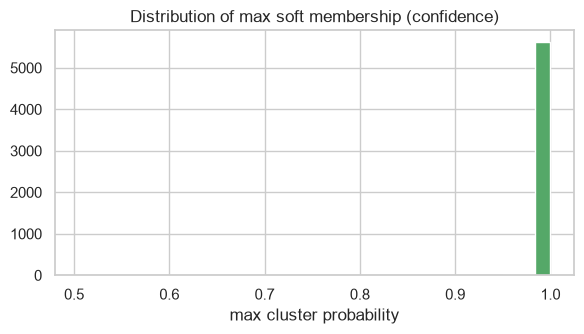

In [3]:
soft = fit_gmm_soft(X, n_components=4, seed=SEED)
print("GMM Silhouette (hard):", soft["silhouette"], "BIC:", soft["bic"])
display(soft_summary(soft["proba"], soft["labels"]))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(soft["proba"].max(axis=1), bins=30, color="C2")
ax.set_title("Distribution of max soft membership (confidence)")
ax.set_xlabel("max cluster probability")
plt.tight_layout()
plt.show()

## 3. Hierarchical two-level cut

**Level 1:** VIP vs rest (protect revenue concentration).  
**Level 2:** split the rest into 3 actionable cores (growth / steady / lapsed-ish).

This matches how budgets are set in practice (VIP program vs mass CRM).

In [4]:
# value axis = monetary from features aligned to core rows
val = core["Monetary"].to_numpy()
hier = hierarchical_two_level(X, seed=SEED, value_axis=val)
print("VIP n=", hier["n_vip"], "rest n=", hier["n_rest"])
print("name_map", hier["name_map"])
core = core.copy()
core["hier_label"] = hier["labels"]
core["hier_name"] = core["hier_label"].map(hier["name_map"])
display(
    core.groupby("hier_name").agg(
        n=("customer_id", "count"),
        mean_M=("Monetary", "mean"),
        mean_R=("Recency", "mean"),
        mean_F=("Frequency", "mean"),
        mean_trend=("MonetaryTrend90", "mean"),
    ).sort_values("mean_M", ascending=False)
)

VIP n= 873 rest n= 4946
name_map {0: 'L1_VIP', 1: 'L2_Core_1', 2: 'L2_Core_2', 3: 'L2_Core_3'}


,n,mean_M,mean_R,mean_F,mean_trend
hier_name,,,,,
L1_VIP,873,8284.941174,59.048110,17.161512,516.729782
L2_Core_1,3852,984.487951,245.299065,3.592939,115.540735
L2_Core_3,814,971.367889,120.648649,3.006143,175.846807
L2_Core_2,280,930.817607,286.217857,3.282143,98.938964


## 4. Rolling time stability (monitoring)

Bootstrap ARI (notebook 02-style production_score) checks resample stability.  
**Rolling as-of re-fits** check whether segments still mean the same thing as time moves.

Rolling re-fit stability:


,asof_prev,asof_curr,n_overlap,ari,size_l1_drift
0,2010-12-05 10:17:30,2011-04-07 11:08:20,4291,0.236053,0.590538
1,2011-04-07 11:08:20,2011-08-08 11:59:10,4741,0.165861,0.385784
2,2011-08-08 11:59:10,2011-12-09 12:50:00,5174,0.185116,0.138578


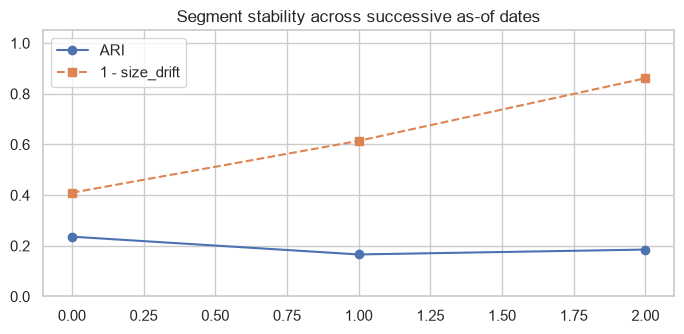

Mean ARI: 0.19567659749631874


In [5]:
stab = rolling_refit_stability(tx, n_points=4, n_clusters=4, seed=SEED)
print("Rolling re-fit stability:")
display(stab)
if len(stab):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(range(len(stab)), stab["ari"], "o-", label="ARI")
    ax.plot(range(len(stab)), 1 - stab["size_l1_drift"], "s--", label="1 - size_drift")
    ax.set_ylim(0, 1.05)
    ax.set_title("Segment stability across successive as-of dates")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("Mean ARI:", float(stab["ari"].mean()))

## 5. Scoring API demo

Production pattern: fit once on training features, `predict` for new rows.
Whales short-circuit to the Whale playbook.

In [6]:
scorer = SegmentScorer(
    cols,
    n_clusters=4,
    log_cols=log_cols,
    seed=SEED,
    whale_threshold=thr,
    monetary_col="Monetary",
)
# fit on full feature table (including whales) so scaler sees full support
scorer.fit(feat)
scored = scorer.predict(feat.head(20))
print("Sample scores:")
display(scored)
print("\nPlaybooks:")
display(scorer.playbook_table())

# export a tiny artifact for demos
art_dir = ROOT / "artifacts"
art_dir.mkdir(exist_ok=True)
sample_path = art_dir / "sample_scores.csv"
scorer.predict(feat).to_csv(sample_path, index=False)
print("Wrote", sample_path, "rows", len(feat))

Sample scores:


,customer_id,segment,cluster_id,is_whale,confidence,recommended_action
0,12346.0,Whale,2,True,0.188391,Dedicated key-account management
1,12347.0,VIP,1,False,0.385312,Protect with high-touch retention
2,12348.0,VIP,1,False,0.364937,Protect with high-touch retention
3,12349.0,AtRisk,0,False,0.233595,Win-back sequence
4,12350.0,LowValue,3,False,0.552254,Low-cost lifecycle only
5,12351.0,LowValue,3,False,0.573441,Low-cost lifecycle only
6,12352.0,VIP,1,False,0.255509,Protect with high-touch retention
7,12353.0,AtRisk,0,False,0.314020,Win-back sequence
8,12354.0,LowValue,3,False,0.315350,Low-cost lifecycle only
9,12355.0,AtRisk,0,False,0.275759,Win-back sequence



Playbooks:


,segment,action,channel,budget_priority,success_metric,offer_hint
0,VIP,Protect with high-touch retention,Account manager + email,high,"Retention rate, repeat AOV",Early access / non-discount perks first
1,Growth,Raise frequency and category breadth,Email / CRM automation,medium,"Orders next 90d, AOV","Bundles, loyalty stamps"
2,AtRisk,Win-back sequence,Email + SMS,medium,Reactivation rate,Modest time-boxed incentive
3,LowValue,Low-cost lifecycle only,Email automation,low,Cost per activated order,Avoid deep discounts
4,Whale,Dedicated key-account management,Human AM,high,"Account retention, NPS","Service SLAs, not coupons"


Wrote /home/ahmad/AI/Customer Segmentation/artifacts/sample_scores.csv rows 5878


## 6. A/B-style experiment design (tutorial, not a live test)

For each playbook, define **who**, **what**, **metric**. That is how you turn
segments into scientific marketing rather than pretty PCA plots.

In [7]:
ab = []
for name, pb in default_playbooks().items():
    ab.append({
        "segment": name,
        "hypothesis": f"If we apply '{pb.action}' to {name}, then {pb.success_metric} improves vs holdout.",
        "channel": pb.channel,
        "budget_priority": pb.budget_priority,
        "primary_metric": pb.success_metric,
        "offer_hint": pb.offer_hint,
        "design": "50/50 random split within segment; 4-week window; guardrail: margin",
    })
ab_df = pd.DataFrame(ab)
display(ab_df)
ab_df.to_csv(art_dir / "ab_experiment_design.csv", index=False)

,segment,hypothesis,channel,budget_priority,primary_metric,offer_hint,design
0,VIP,If we apply 'Protect with high-touch retention...,Account manager + email,high,"Retention rate, repeat AOV",Early access / non-discount perks first,50/50 random split within segment; 4-week wind...
1,Growth,If we apply 'Raise frequency and category brea...,Email / CRM automation,medium,"Orders next 90d, AOV","Bundles, loyalty stamps",50/50 random split within segment; 4-week wind...
2,AtRisk,"If we apply 'Win-back sequence' to AtRisk, the...",Email + SMS,medium,Reactivation rate,Modest time-boxed incentive,50/50 random split within segment; 4-week wind...
3,LowValue,If we apply 'Low-cost lifecycle only' to LowVa...,Email automation,low,Cost per activated order,Avoid deep discounts,50/50 random split within segment; 4-week wind...
4,Whale,If we apply 'Dedicated key-account management'...,Human AM,high,"Account retention, NPS","Service SLAs, not coupons",50/50 random split within segment; 4-week wind...


## 7. How the full advanced track improves on 01–03

| Layer | 01–03 baseline | Advanced 04–06 | Why better for production |
|-------|----------------|----------------|---------------------------|
| Features | R,F,M (or 6 spends) | RFM+ trajectories, cancels, tenure | Separates real behaviors |
| Outliers | Winsorize only | Whale **policy** segment | Ops + geometry |
| Evaluation | Silhouette / CH / DB | **Future £ & retention** | Business truth |
| Labels | Hard only | Soft GMM + hierarchy | Budgeting reality |
| Monitoring | Seed stability | Rolling as-of ARI | Drift detection |
| Delivery | Notebook tables | **Scorer + playbooks + A/B design** | Runnable CRM loop |

Keep 01–03 for teaching fundamentals. Use 04–06 when you need **portfolio-grade / production-minded** depth.

In [8]:
print("DONE notebook 06")
print("Artifacts:", list(art_dir.glob("*")))

DONE notebook 06
Artifacts: [PosixPath('/home/ahmad/AI/Customer Segmentation/artifacts/ab_experiment_design.csv'), PosixPath('/home/ahmad/AI/Customer Segmentation/artifacts/sample_scores.csv')]
